In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("semrepo-20k.csv")

num_cols = [
    "stars","forks","watchers","issues","openIssues",
    "closedIssues","comments","contributors","total_commits"
]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["created"] = pd.to_datetime(df["created"], errors="coerce")

# RQ1 — REPRODUCIBILITY & MAINTENANCE METRICS

# 1. Issue closure rate (core RQ metric)
df["closure_rate"] = df["closedIssues"] / (df["closedIssues"] + df["openIssues"])
df["closure_rate"] = df["closure_rate"].replace([np.inf, -np.inf], np.nan)

df["total_issues"] = df["closedIssues"] + df["openIssues"]
df["closure_rate"] = np.where(
    df["total_issues"] > 0,
    df["closedIssues"] / df["total_issues"],
    np.nan
)

# 2. Activity level (your key reproducibility signal)
df["log_commits"] = np.log1p(df["total_commits"])
df["log_contributors"] = np.log1p(df["contributors"])
# 3. “Repository Health Index” 
df["repo_health"] = (
    df["log_commits"] +
    df["log_contributors"] +
    np.log1p(df["stars"]) +
    np.log1p(df["forks"])
)

df["is_low_activity"] = (
    (df["total_commits"].fillna(0) < 5) &
    (df["contributors"].fillna(0) <= 1) &
    (df["stars"].fillna(0) < 10)
)

# activity = total_commits + num_contributors + stars

df["repro_risk"] = (
    (1 - df["closure_rate"].fillna(0)) * 1.0 +   # continuous
    (df["contributors"].fillna(0) < 2).astype(int) * 1.0 +
    (df["total_commits"].fillna(0) < 10).astype(int) * 1.0
)
# normalize
df["repro_risk"] = df["repro_risk"] / 3.0


In [2]:
print("\n=== DATASET OVERVIEW ===")
print("Repos:", len(df))

print("\n=== BASIC STATS ===")
print(f"Avg stars: {df['stars'].mean():.2f}")
print(f"Median stars: {df['stars'].median():.2f}")
print(f"Avg contributors: {df['contributors'].mean():.2f}")
print(f"Avg commits: {df['total_commits'].mean():.2f}")
print(f"Avg closure rate: {df['closure_rate'].mean():.2f}")

print("\n=== REPRODUCIBILITY ===")
print(f"High-risk repos (%): {(df['repro_risk'] > 0.66).mean()*100:.1f}%")
print(f"Medium-risk repos (%): {((df['repro_risk'] > 0.33) & (df['repro_risk'] <= 0.66)).mean()*100:.1f}%")
print(f"Low-risk repos (%): {(df['repro_risk'] <= 0.33).mean()*100:.1f}%")

print(f"Low-activity repos (%): {df['is_low_activity'].mean()*100:.1f}%")


=== DATASET OVERVIEW ===
Repos: 20000

=== BASIC STATS ===
Avg stars: 269.44
Median stars: 24.00
Avg contributors: 4.96
Avg commits: 252.57
Avg closure rate: 0.59

=== REPRODUCIBILITY ===
High-risk repos (%): 46.4%
Medium-risk repos (%): 26.9%
Low-risk repos (%): 26.6%
Low-activity repos (%): 8.3%


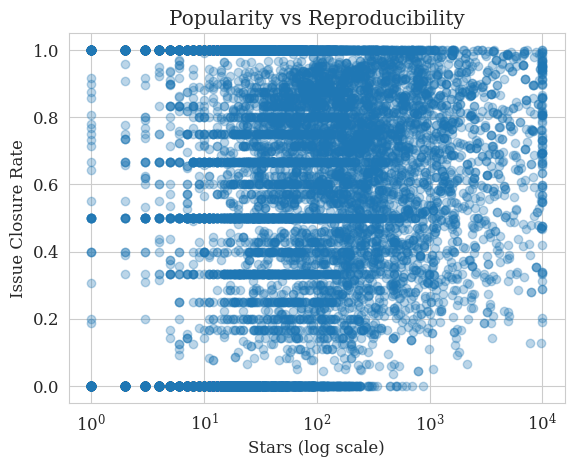

In [20]:
import matplotlib.pyplot as plt

plt.scatter(df["stars"], df["closure_rate"], alpha=0.3)
plt.xscale("log")
plt.xlabel("Stars (log scale)")
plt.ylabel("Issue Closure Rate")
plt.title("Popularity vs Reproducibility")
plt.show()

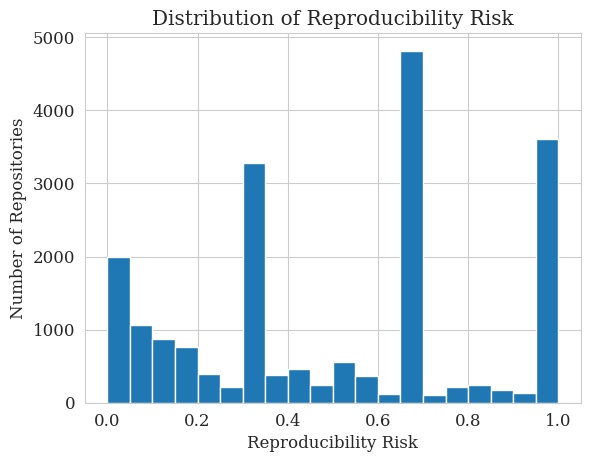

In [30]:
import matplotlib.pyplot as plt

plt.scatter(df["stars"], df["closure_rate"], alpha=0.3)
plt.xscale("log")
plt.xlabel("Stars (log scale)")
plt.ylabel("Issue Closure Rate")
plt.title("Popularity vs Reproducibility")
plt.show()


df["repro_risk"].hist(bins=20)
plt.xlabel("Reproducibility Risk")
plt.ylabel("Number of Repositories")
plt.title("Distribution of Reproducibility Risk")
plt.show()

plt.scatter(df["stars"], df["closure_rate"], alpha=0.3)
plt.xscale("log")
plt.xlabel("Number of Stars (log scale)")
plt.ylabel("Issue Closure Rate")
plt.title("Repository Popularity vs Maintenance")
plt.show()

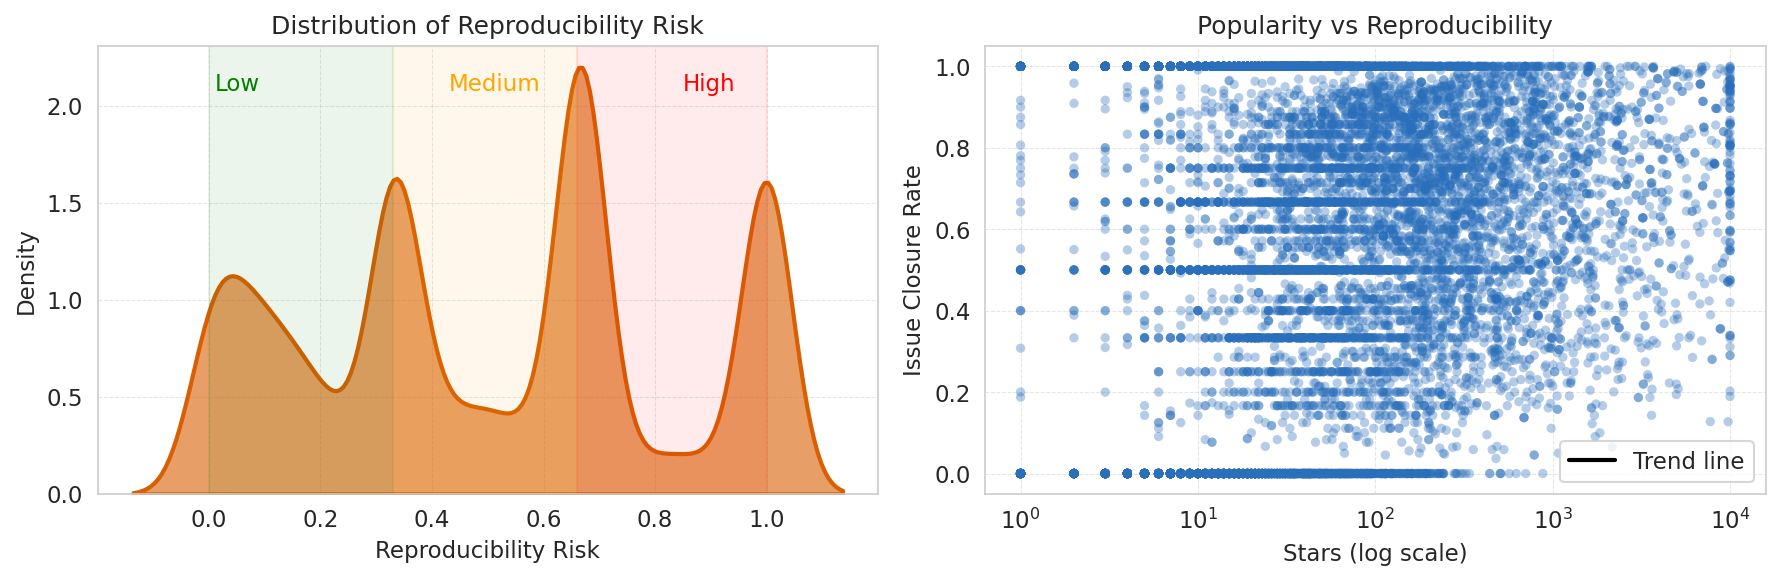

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

# -------------------------
# Style (paper-ready)
# -------------------------
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# =========================================================
# (1) LEFT: KDE of reproducibility risk
# =========================================================
sns.kdeplot(
    df["repro_risk"],
    ax=axes[0],
    fill=True,
    color="#d95f02",
    alpha=0.6,
    linewidth=2
)

axes[0].set_xlabel("Reproducibility Risk")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution of Reproducibility Risk")

# --- Annotate risk regions (adjust thresholds if needed)
low_thr, med_thr = 0.33, 0.66

axes[0].axvspan(0, low_thr, alpha=0.08, color="green")
axes[0].axvspan(low_thr, med_thr, alpha=0.08, color="orange")
axes[0].axvspan(med_thr, 1, alpha=0.08, color="red")

axes[0].text(0.15, 0.9, "Low", transform=axes[0].transAxes, color="green")
axes[0].text(0.45, 0.9, "Medium", transform=axes[0].transAxes, color="orange")
axes[0].text(0.75, 0.9, "High", transform=axes[0].transAxes, color="red")

# =========================================================
# (2) RIGHT: Scatter + regression trendline
# =========================================================
x = df["stars"]
y = df["closure_rate"]

axes[1].scatter(
    x, y,
    alpha=0.35,
    s=20,
    color="#2a6fbb",
    edgecolor="none"
)

# log transform for regression stability
log_x = np.log10(x + 1)
slope, intercept, _, _, _ = linregress(log_x, y)

x_line = np.linspace(log_x.min(), log_x.max(), 200)
y_line = slope * x_line + intercept

axes[1].plot(
    10**x_line,
    y_line,
    color="black",
    linewidth=2,
    label="Trend line"
)

axes[1].set_xscale("log")
axes[1].set_xlabel("Stars (log scale)")
axes[1].set_ylabel("Issue Closure Rate")
axes[1].set_title("Popularity vs Reproducibility")
axes[1].legend()

# Grid styling
for ax in axes:
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()

# =========================================================
# Export for LaTeX
# =========================================================
plt.savefig("figure_reproducibility.pdf", format="pdf", bbox_inches="tight")
# plt.savefig("figure_reproducibility.svg", format="svg", bbox_inches="tight")

plt.show()

In [3]:
from scipy.stats import spearmanr
def print_corr(name, x, y):
    corr, p = spearmanr(x, y, nan_policy="omit")
    print(f"{name}: rho={corr:.3f}, p={p:.3g}")

print("\n=== CORRELATIONS ===")

# A. Are popular repos more reproducible?
print_corr("Are popular repos more reproducible?\n Stars vs closure rate", df["stars"], df["closure_rate"])
print_corr("Stars vs commits", df["stars"], df["total_commits"])
# B. Do maintained repos have more contributors?
print_corr("Do maintained repos have more contributors?\n Contributors vs closure rate", df["contributors"], df["closure_rate"])
# C. Do commits correlate with issue resolution?
print_corr("Do commits correlate with issue resolution?\n Commits vs closure rate", df["total_commits"], df["closure_rate"])


=== CORRELATIONS ===
Are popular repos more reproducible?
 Stars vs closure rate: rho=0.082, p=1.58e-19
Stars vs commits: rho=0.344, p=0
Do maintained repos have more contributors?
 Contributors vs closure rate: rho=0.144, p=2.43e-56
Do commits correlate with issue resolution?
 Commits vs closure rate: rho=0.193, p=1.53e-101


In [4]:
high_star = df[df["stars"] > 100]
low_star = df[df["stars"] < 10]

#popular repos are more reproducible
print("\n=== HIGH vs LOW POPULARITY ===")
print(f"Closure rate (high stars): {high_star['closure_rate'].mean():.2f}")
print(f"Closure rate (low stars): {low_star['closure_rate'].mean():.2f}")


=== HIGH vs LOW POPULARITY ===
Closure rate (high stars): 0.65
Closure rate (low stars): 0.49


In [5]:
print("\n=== TOP HIGH-RISK REPOS ===")
print(df.sort_values("repro_risk", ascending=False)[
    ["repoEntity", "stars", "contributors", "total_commits", "repro_risk"]
].head(10))


=== TOP HIGH-RISK REPOS ===
                                              repoEntity  stars  contributors  \
19980   https://semrepo.org/repository/valterlej/zsarcap   10.0           1.0   
19977  https://semrepo.org/repository/matsushima-lab/...    NaN           1.0   
19990  https://semrepo.org/repository/jeya-maria-jose...   13.0           1.0   
2      https://semrepo.org/repository/pluflou/mlrevie...    NaN           1.0   
9265   https://semrepo.org/repository/harunshimanto/n...    8.0           NaN   
9295   https://semrepo.org/repository/jungtaekkim/los...    NaN           1.0   
9294   https://semrepo.org/repository/luna97/matrix-a...    NaN           1.0   
9292   https://semrepo.org/repository/cmendl/ternary_...    2.0           1.0   
9291       https://semrepo.org/repository/danielastep/sc    NaN           NaN   
9286   https://semrepo.org/repository/alban-grastien/...    NaN           1.0   

       total_commits  repro_risk  
19980            5.0         1.0  
19977    

In [6]:
high_risk = df[df["repro_risk"] > 0.66]
low_risk = df[df["repro_risk"] <= 0.33]

print("\n=== HIGH vs LOW RISK COMPARISON ===")

def compare(metric):
    print(f"\n{metric}:")
    print(f"  High risk mean: {high_risk[metric].mean():.2f}")
    print(f"  Low risk mean:  {low_risk[metric].mean():.2f}")

compare("contributors")
compare("total_commits")
compare("stars")
compare("closure_rate")

from scipy.stats import mannwhitneyu

def test(metric):
    stat, p = mannwhitneyu(
        high_risk[metric].dropna(),
        low_risk[metric].dropna(),
        alternative="two-sided"
    )
    print(f"{metric}: p={p:.6g}")

print("\n=== SIGNIFICANCE TESTS ===")
test("contributors")
test("total_commits")
test("stars")


=== HIGH vs LOW RISK COMPARISON ===

contributors:
  High risk mean: 1.06
  Low risk mean:  13.63

total_commits:
  High risk mean: 24.81
  Low risk mean:  734.76

stars:
  High risk mean: 30.96
  Low risk mean:  789.86

closure_rate:
  High risk mean: 0.33
  Low risk mean:  0.72

=== SIGNIFICANCE TESTS ===
contributors: p=0
total_commits: p=0
stars: p=0


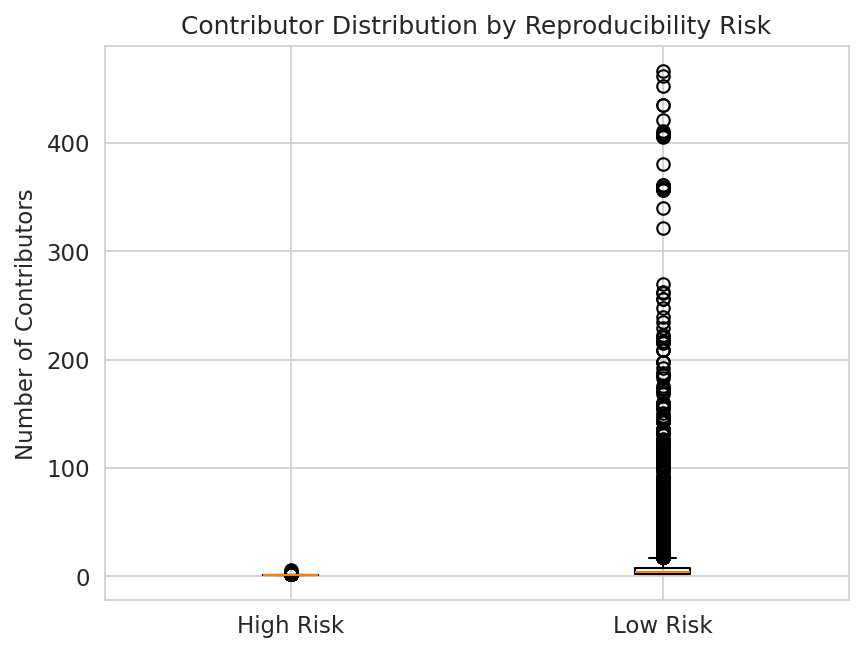

In [39]:
import matplotlib.pyplot as plt

plt.boxplot([
    high_risk["contributors"].dropna(),
    low_risk["contributors"].dropna()
])

plt.xticks([1,2], ["High Risk", "Low Risk"])
plt.ylabel("Number of Contributors")
plt.title("Contributor Distribution by Reproducibility Risk")
plt.show()

In [37]:
##########

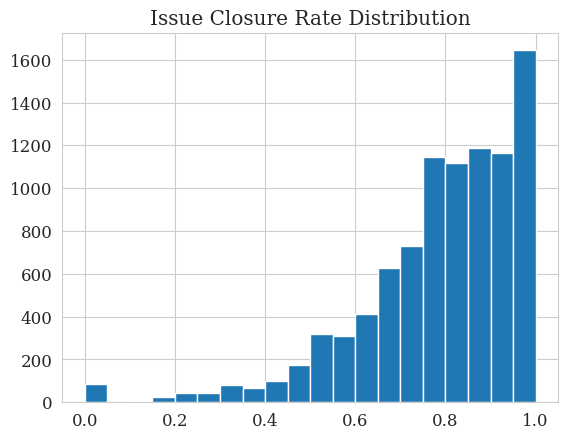

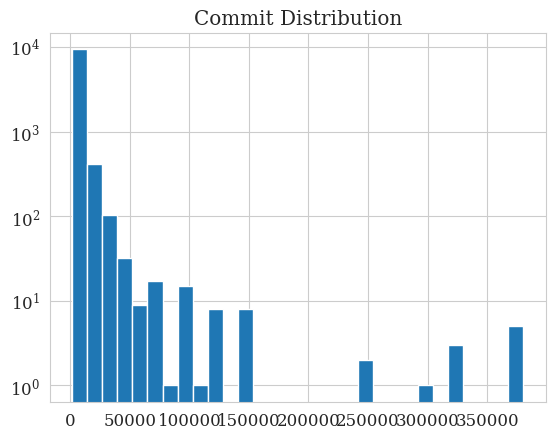

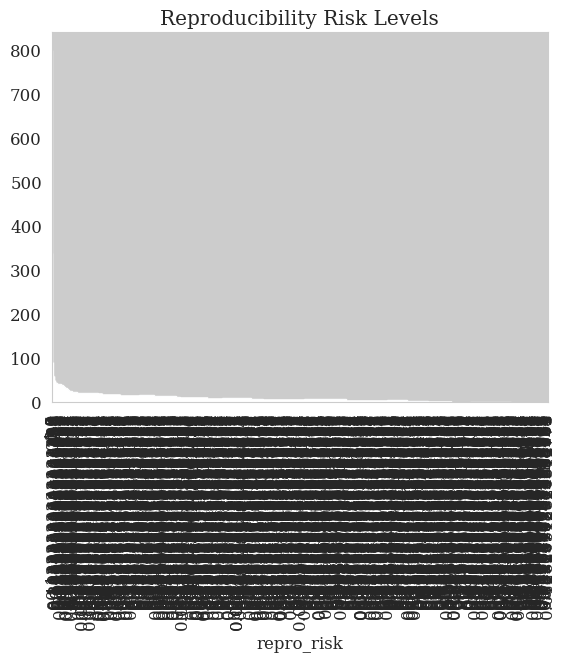

In [12]:
import matplotlib.pyplot as plt

df["closure_rate"].hist(bins=20)
plt.title("Issue Closure Rate Distribution")
plt.show()

df["total_commits"].hist(bins=30)
plt.title("Commit Distribution")
plt.yscale("log")
plt.show()

df["repro_risk"].value_counts().plot(kind="bar")
plt.title("Reproducibility Risk Levels")
plt.show()

In [14]:
df.sort_values("repro_risk", ascending=False)[
    ["repoEntity","githubUrl","stars","contributors","total_commits","closure_rate"]
].head(20)

,repoEntity,githubUrl,stars,contributors,total_commits,closure_rate
1458,https://semrepo.org/repository/pourmalek/covid...,https://github.com/pourmalek/covidvisualizedco...,NaN,1,8250,NaN
1459,https://semrepo.org/repository/pourmalek/covid...,https://github.com/pourmalek/covidvisualizedco...,NaN,1,8250,NaN
1460,https://semrepo.org/repository/pourmalek/covid...,https://github.com/pourmalek/covidvisualizedco...,NaN,1,8250,NaN
1461,https://semrepo.org/repository/pourmalek/covid...,https://github.com/pourmalek/covidvisualizedco...,NaN,1,8250,NaN
1462,https://semrepo.org/repository/pourmalek/covid...,https://github.com/pourmalek/covidvisualizedco...,NaN,1,8250,NaN
1463,https://semrepo.org/repository/pourmalek/covid...,https://github.com/pourmalek/covidvisualizedco...,NaN,1,8250,NaN
1464,https://semrepo.org/repository/pourmalek/covid...,https://github.com/pourmalek/covidvisualizedco...,NaN,1,8250,NaN
1465,https://semrepo.org/repository/pourmalek/covid...,https://github.com/pourmalek/covidvisualizedco...,NaN,1,8250,NaN
1466,https://semrepo.org/repository/pourmalek/covid...,https://github.com/pourmalek/covidvisualizedco...,NaN,1,8250,NaN
1467,https://semrepo.org/repository/pourmalek/covid...,https://github.com/pourmalek/covidvisualizedco...,NaN,1,8250,NaN
